In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

In [2]:
### change file name
### change P,e,Z
### change x_max

In [3]:
path = "/home/poornima/Documents/BSE_METISSE_project/output_binary/"
file_name = "01500M_01000M.dat"
full_path = os.path.join(path, file_name)

data = np.loadtxt(full_path) 

# Remove the last row
data = data[:-1, :]

In [4]:
x_max = 30

e = 0.4
p = 15
Z = 0.02

In [5]:
base_name = Path(file_name).stem

In [6]:
first_row = data[0]          
print(first_row)

[0.0000e+00 1.0000e+00 1.0000e+00 1.5000e+01 1.0000e+01 5.6269e+00
 3.2369e+00 6.7030e-01 5.6720e-01 9.1800e-01 8.7140e-01 4.2707e+00
 3.7215e+00 2.1270e+03 2.8550e+03 0.0000e+00 0.0000e+00 1.0000e-10
 1.0000e-10 1.0000e-10 1.0000e-10 1.2300e+01 0.0000e+00]


In [7]:
num_cols = data.shape[1]  # number of columns
print("Number of columns:", num_cols)

num_cols = data.shape[0]  # number of rows
print("Number of Rows:", num_cols)

Number of columns: 23
Number of Rows: 3218


In [8]:
# Define the column names
columns = [
    "Time",
    "stellar_type_1","stellar_type_2","initial_mass_1","initial_mass_2", "current_mass_1","current_mass_2","log10_r_1","log10_r_2",
    "R1/ROL1","R2/ROL2","log10_L_1","log10_L_2",
    "spin_1","spin_2","mass_loss_rate_1","mass_loss_rate_2","convective_envelope_mass_1","convective_envelope_mass_2",
    "envelope_radius_1","envelope_radius_2","sep_Rsun","ecc"]
    
df = pd.DataFrame(data, columns=columns)

df.head()

,Time,stellar_type_1,stellar_type_2,initial_mass_1,initial_mass_2,current_mass_1,current_mass_2,log10_r_1,log10_r_2,R1/ROL1,...,spin_1,spin_2,mass_loss_rate_1,mass_loss_rate_2,convective_envelope_mass_1,convective_envelope_mass_2,envelope_radius_1,envelope_radius_2,sep_Rsun,ecc
0,0.0000,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9180,...,2127.0,2855.0,0.000000e+00,0.000000e+00,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.30,0.0
1,0.0122,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9182,...,2295.0,2507.0,-1.452000e-19,1.685000e-20,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.30,0.0
2,0.0245,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9172,...,2296.0,2376.0,0.000000e+00,0.000000e+00,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.31,0.0
3,0.0367,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9167,...,2292.0,2324.0,-5.057000e-20,-6.410000e-20,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.32,0.0
4,0.0489,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9165,...,2290.0,2303.0,-7.259000e-20,8.415000e-21,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.32,0.0


In [9]:
# Compute log10Teff as a new column
df["log10Teff_1"] = 3 + 0.25 * (np.log10(1130) + df["log10_L_1"] - 2 * df["log10_r_1"])


df["log10Teff_2"] = 3 + 0.25 * (np.log10(1130) + df["log10_L_2"] - 2 * df["log10_r_2"])

df.head()

,Time,stellar_type_1,stellar_type_2,initial_mass_1,initial_mass_2,current_mass_1,current_mass_2,log10_r_1,log10_r_2,R1/ROL1,...,mass_loss_rate_1,mass_loss_rate_2,convective_envelope_mass_1,convective_envelope_mass_2,envelope_radius_1,envelope_radius_2,sep_Rsun,ecc,log10Teff_1,log10Teff_2
0,0.0000,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9180,...,0.000000e+00,0.000000e+00,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.30,0.0,4.495795,4.410045
1,0.0122,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9182,...,-1.452000e-19,1.685000e-20,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.30,0.0,4.495795,4.410045
2,0.0245,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9172,...,0.000000e+00,0.000000e+00,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.31,0.0,4.495795,4.410045
3,0.0367,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9167,...,-5.057000e-20,-6.410000e-20,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.32,0.0,4.495795,4.410045
4,0.0489,1.0,1.0,15.0,10.0,5.6269,3.2369,0.6703,0.5672,0.9165,...,-7.259000e-20,8.415000e-21,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,12.32,0.0,4.495795,4.410045


In [10]:
kstar_translator = [
    {'long': 'Main Sequence (Low mass)', 'short': 'MS < 0.7', 'colour':(0.6, 1.0, 0.0, 1.0) }, ##(0.996078, 0.843476, 0.469158, 1.0)
    {'long': 'Main Sequence', 'short': 'MS', 'colour': (0.996078, 0.843476, 0.469158, 1.0)},
    {'long': 'Hertzsprung Gap', 'short': 'HG', 'colour':(0.939608, 0.471373, 0.094902, 1.0) },  ##
    {'long': 'First Giant Branch', 'short': 'FGB', 'colour': (0.0, 0.9, 0.9, 1.0)},  ##(0.716186, 0.833203, 0.916155, 1.0)
    {'long': 'Core Helium Burning', 'short': 'CHeB', 'colour': (0.29098, 0.59451, 0.78902, 1.0)},
    {'long': 'Early AGB', 'short': 'EAGB', 'colour': (0.294902, 0.690196, 0.384314, 1.0)},
    {'long': 'Thermally Pulsing AGB', 'short': 'TPAGB',
     'colour': (0.723122, 0.889612, 0.697178, 1.0)},
    {'long': 'Helium Main Sequence', 'short': 'HeMS', 'colour': (0.254627, 0.013882, 0.615419, 1.0)},
    {'long': 'Helium Hertsprung Gap', 'short': 'HeHG', 'colour': (0.562738, 0.051545, 0.641509, 1.0)},
    {'long': 'Helium Giant Branch', 'short': 'HeGB', 'colour': (0.798216, 0.280197, 0.469538, 1.0)},
    {'long': 'Helium White Dwarf', 'short': 'HeWD', 'colour': (0.368166, 0.232828, 0.148275, 1.0)},
    {'long': 'Carbon/Oxygen White Dwarf', 'short': 'COWD', 'colour': (0.620069, 0.392132, 0.249725, 1.0)},
    {'long': 'Oxygen/Neon White Dwarf', 'short': 'ONeWD', 'colour': (0.867128, 0.548372, 0.349225, 1.0)},
    {'long': 'Neutron Star', 'short': 'NS', 'colour': (0.501961, 0.501961, 0.501961, 1.0)},
    {'long': 'Black Hole', 'short': 'BH', 'colour': 'black'},
    {'long': 'Massless Remnant', 'short': 'MR', 'colour': (1.0, 1.0, 0.0, 1.0)}
    
]

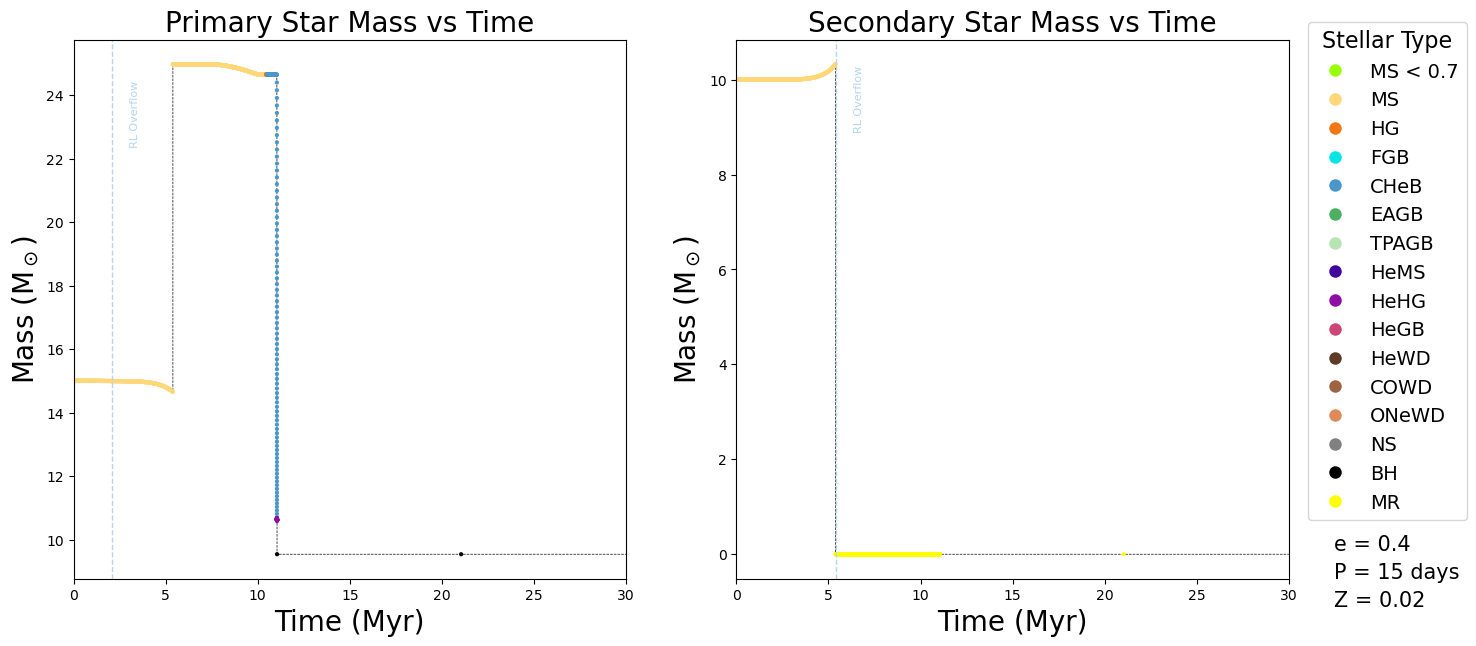

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    df["Time"], 
    df["initial_mass_1"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_1"]], 
    s=4
)
ax1.set_xlim(xmin=0.0, xmax=x_max)
ax1.plot(df["Time"], df["initial_mass_1"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlabel('Time (Myr)',fontsize=20)
ax1.set_ylabel(r'Mass (M$_\odot$)',fontsize=20)
ax1.set_title('Primary Star Mass vs Time',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    df["Time"], 
    df["initial_mass_2"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_2"]], 
    s=4
)
ax2.set_xlim(xmin=0.0, xmax=x_max)
ax2.plot(df["Time"], df["initial_mass_2"], lw=0.5, color='black', linestyle='--',zorder=-1)
ax2.set_xlabel('Time (Myr)',fontsize=20)
ax2.set_ylabel(r'Mass (M$_\odot$)',fontsize=20)
ax2.set_title('Secondary Star Mass vs Time',fontsize=20)


# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(0, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=14,
    title_fontsize=16,
    loc='center right',
    bbox_to_anchor=(0.9, 0.55),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

# Primary star - see mass transfer
mask_primary = df["R1/ROL1"] >= 1
if mask_primary.any():  # only if there is at least one True
    mass_transfer_time_primary = df["Time"][mask_primary].min()
    # draw vertical dashed line and annotate
    ax1.axvline(x=mass_transfer_time_primary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax1.text(mass_transfer_time_primary+1, ax1.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

# Secondary star - see mass transfer
mask_secondary = df["R2/ROL2"] >= 1
if mask_secondary.any():
    mass_transfer_time_secondary = df["Time"][mask_secondary].min()
    ax2.axvline(x=mass_transfer_time_secondary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax2.text(mass_transfer_time_secondary+1, ax2.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "Mass_vs_Time"


save_name = f"{base_name}_{img_title}.png"
save_dir = "./output_plots/"
save_path = os.path.join(save_dir, save_name)

fig.savefig(save_path, dpi=300, bbox_inches="tight")

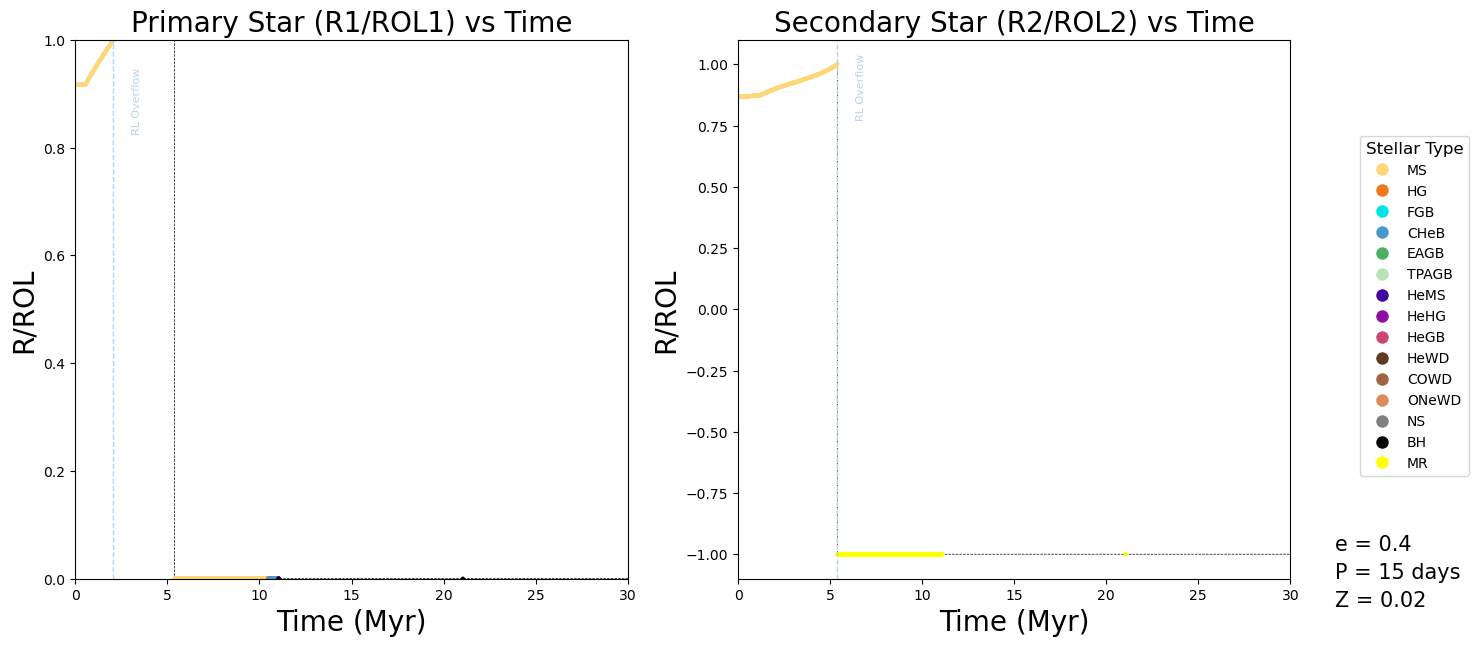

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    df["Time"], 
    df["R1/ROL1"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_1"]], 
    s=4
)
ax1.set_xlim(xmin=0.0, xmax=x_max)
ax1.set_ylim(ymin=0.0, ymax=1)
ax1.plot(df["Time"], df["R1/ROL1"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlabel('Time (Myr)',fontsize=20)
ax1.set_ylabel('R/ROL',fontsize=20)
ax1.set_title('Primary Star (R1/ROL1) vs Time',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    df["Time"], 
    df["R2/ROL2"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_2"]], 
    s=4
)
ax2.set_xlim(xmin=0.0, xmax=x_max)
ax2.plot(df["Time"], df["R2/ROL2"], lw=0.5, color='black',linestyle='--', zorder=-1)
ax2.set_xlabel('Time (Myr)',fontsize=20)
ax2.set_ylabel('R/ROL',fontsize=20)
ax2.set_title('Secondary Star (R2/ROL2) vs Time',fontsize=20)

# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(1, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=10,
    title_fontsize=12,
    loc='center right',
    bbox_to_anchor=(0.9, 0.5),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

# Primary star - see mass transfer
mask_primary = df["R1/ROL1"] >= 1
if mask_primary.any():  # only if there is at least one True
    mass_transfer_time_primary = df["Time"][mask_primary].min()
    # draw vertical dashed line and annotate
    ax1.axvline(x=mass_transfer_time_primary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax1.text(mass_transfer_time_primary+1, ax1.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

# Secondary star - see mass transfer
mask_secondary = df["R2/ROL2"] >= 1
if mask_secondary.any():
    mass_transfer_time_secondary = df["Time"][mask_secondary].min()
    ax2.axvline(x=mass_transfer_time_secondary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax2.text(mass_transfer_time_secondary+1, ax2.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "R_over_ROL_vs_Time"


save_name = f"{base_name}_{img_title}.png"
save_dir = "./output_plots/"
save_path = os.path.join(save_dir, save_name)

fig.savefig(save_path, dpi=300, bbox_inches="tight")

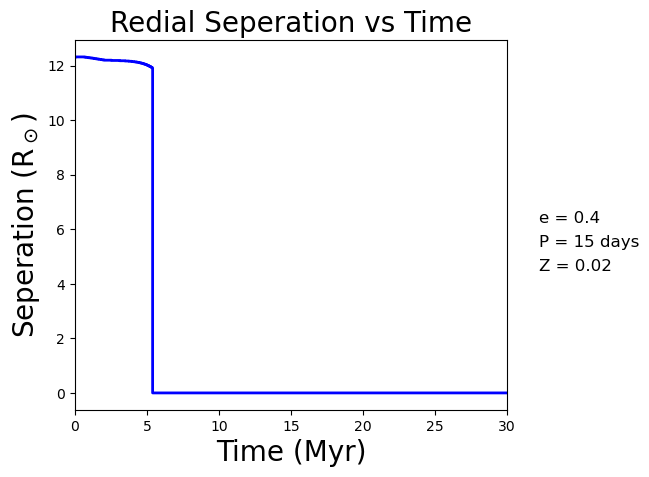

In [13]:
fig, ax = plt.subplots()

ax.set_xlim(xmin=0.0, xmax=x_max)
ax.plot(df["Time"], df["sep_Rsun"], lw=2, color='blue' )

ax.set_xlabel(r'Time (Myr)',fontsize=20)
ax.set_ylabel(r'Seperation (R$_\odot$)',fontsize=20)
ax.set_title('Redial Seperation vs Time',fontsize=20)

y0 = 0.50
dy = 0.05

fig.text(0.85, y0, f'e = {e}', fontsize=12)
fig.text(0.85, y0 - dy, f'P = {p} days', fontsize=12)
fig.text(0.85, y0-2*dy, f'Z = {Z}', fontsize=12)



fig.subplots_adjust(right=0.8)   # leave space on the right

img_title = "Seperation_vs_Time"


save_name = f"{base_name}_{img_title}.png"
save_dir = "./output_plots/"
save_path = os.path.join(save_dir, save_name)

fig.savefig(save_path, dpi=300, bbox_inches="tight")

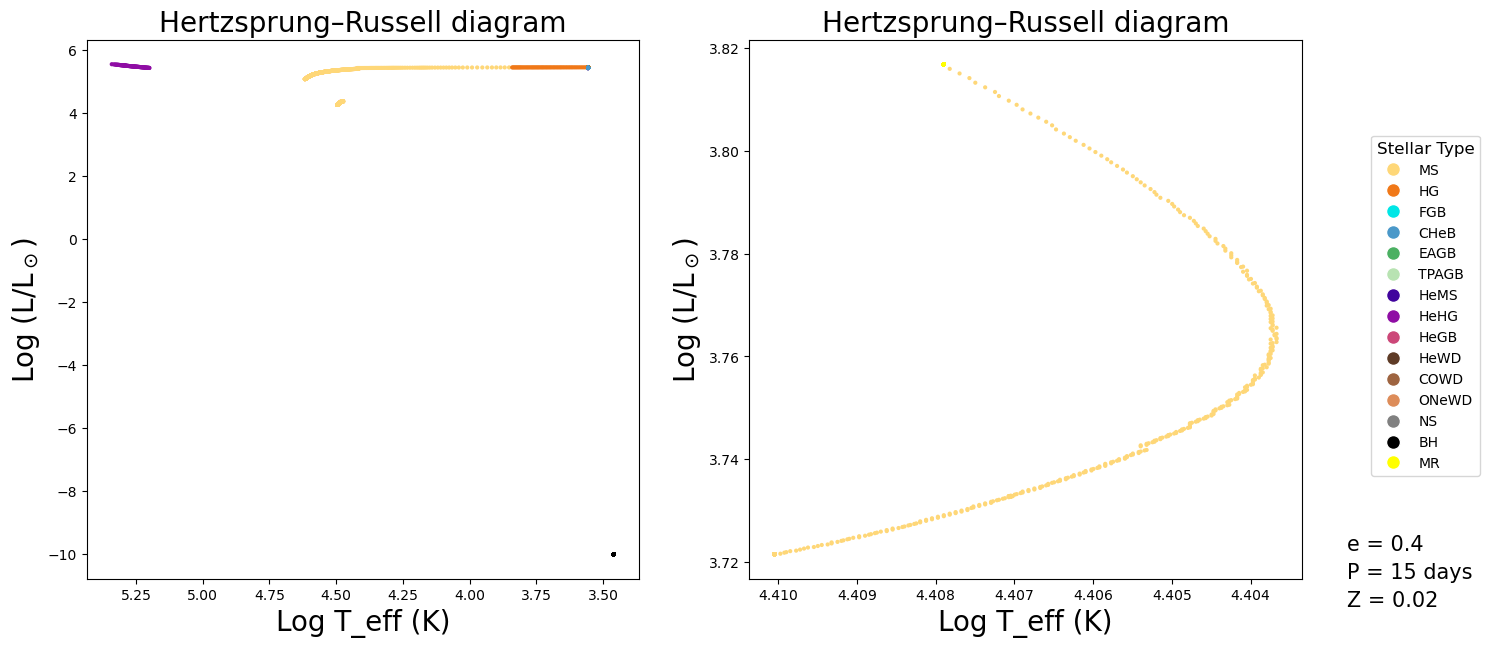

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    df["log10Teff_1"], 
    df["log10_L_1"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_1"]], 
    s=4
)
# ax1.set_xlim(xmin=0.0, xmax=x_max)
# ax1.set_ylim(ymin=0.0, ymax=1)
#ax1.plot(df["log10Teff_1"], df["log10_L_1"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlabel('Log T_eff (K)',fontsize=20)
ax1.set_ylabel(r'Log (L/L$_\odot$)', fontsize=20)
ax1.invert_xaxis()
ax1.set_title('Hertzsprung–Russell diagram',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    df["log10Teff_2"], 
    df["log10_L_2"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_2"]], 
    s=4
)
#ax2.set_xlim(xmin=0.0, xmax=x_max)
#ax2.plot(df["log10Teff_2"], df["log10_L_2"], lw=0.5, color='black',linestyle='--', zorder=-1)
ax2.set_xlabel('Log T_eff (K)',fontsize=20)
ax2.set_ylabel(r'Log (L/L$_\odot$)', fontsize=20)
ax2.invert_xaxis()
ax2.set_title('Hertzsprung–Russell diagram',fontsize=20)

# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(1, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=10,
    title_fontsize=12,
    loc='center right',
    bbox_to_anchor=(0.9, 0.5),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "HR_diag"


save_name = f"{base_name}_{img_title}.png"
save_dir = "./output_plots/"
save_path = os.path.join(save_dir, save_name)

fig.savefig(save_path, dpi=300, bbox_inches="tight")

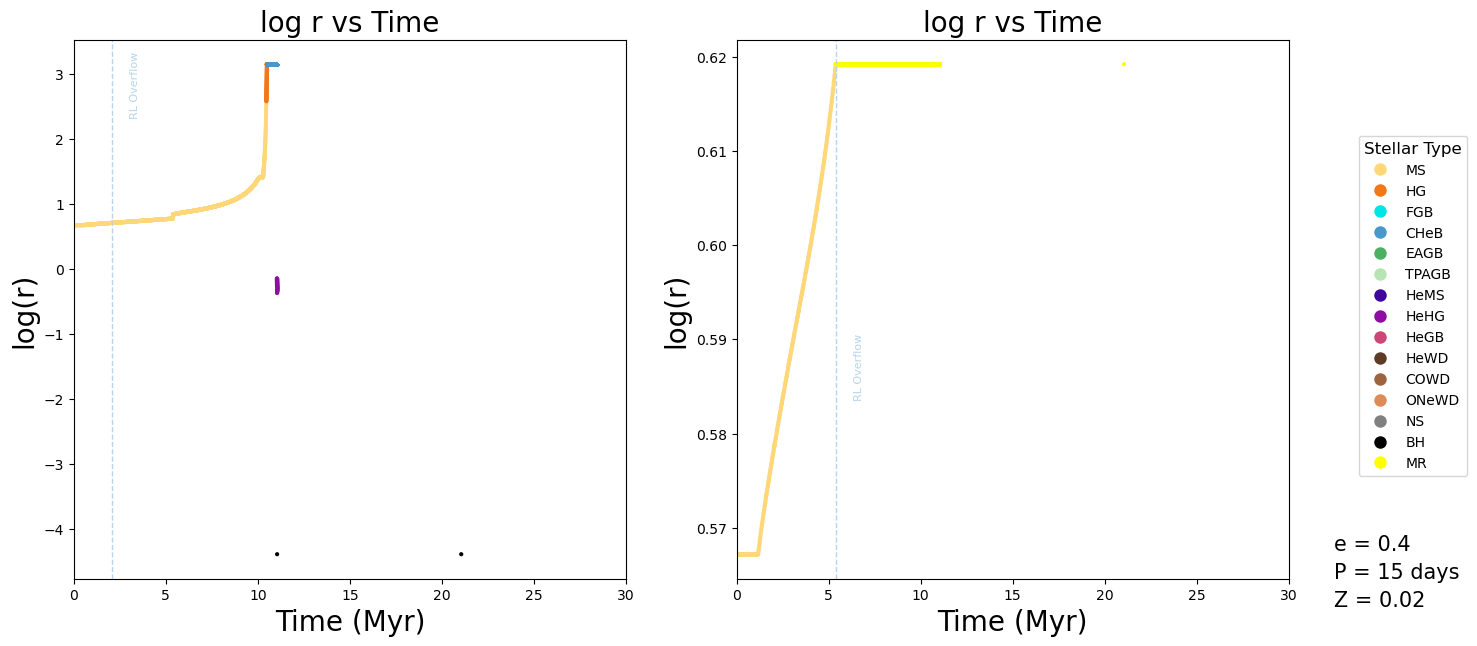

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    df["Time"], 
    df["log10_r_1"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_1"]], 
    s=4
)
#ax1.plot(df["Time"], df["log10_r_1"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlim(xmin=0.0, xmax=x_max)
ax1.set_xlabel('Time (Myr)',fontsize=20)
ax1.set_ylabel('log(r)',fontsize=20)
ax1.set_title('log r vs Time',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    df["Time"], 
    df["log10_r_2"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_2"]], 
    s=4
)
#ax2.plot(df["Time"], df["log10_r_2"], lw=0.5, color='black',linestyle='--', zorder=-1)
ax2.set_xlim(xmin=0.0, xmax=x_max)
ax2.set_xlabel('Time (Myr)',fontsize=20)
ax2.set_ylabel('log(r)',fontsize=20)
ax2.set_title('log r vs Time',fontsize=20)

# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(1, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=10,
    title_fontsize=12,
    loc='center right',
    bbox_to_anchor=(0.9, 0.5),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

# Primary star - see mass transfer
mask_primary = df["R1/ROL1"] >= 1
if mask_primary.any():  # only if there is at least one True
    mass_transfer_time_primary = df["Time"][mask_primary].min()
    # draw vertical dashed line and annotate
    ax1.axvline(x=mass_transfer_time_primary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax1.text(mass_transfer_time_primary+1, ax1.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

# Secondary star - see mass transfer
mask_secondary = df["R2/ROL2"] >= 1
if mask_secondary.any():
    mass_transfer_time_secondary = df["Time"][mask_secondary].min()
    ax2.axvline(x=mass_transfer_time_secondary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax2.text(mass_transfer_time_secondary+1, ax2.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "logR_vs_Time"


save_name = f"{base_name}_{img_title}.png"
save_dir = "./output_plots/"
save_path = os.path.join(save_dir, save_name)

fig.savefig(save_path, dpi=300, bbox_inches="tight")

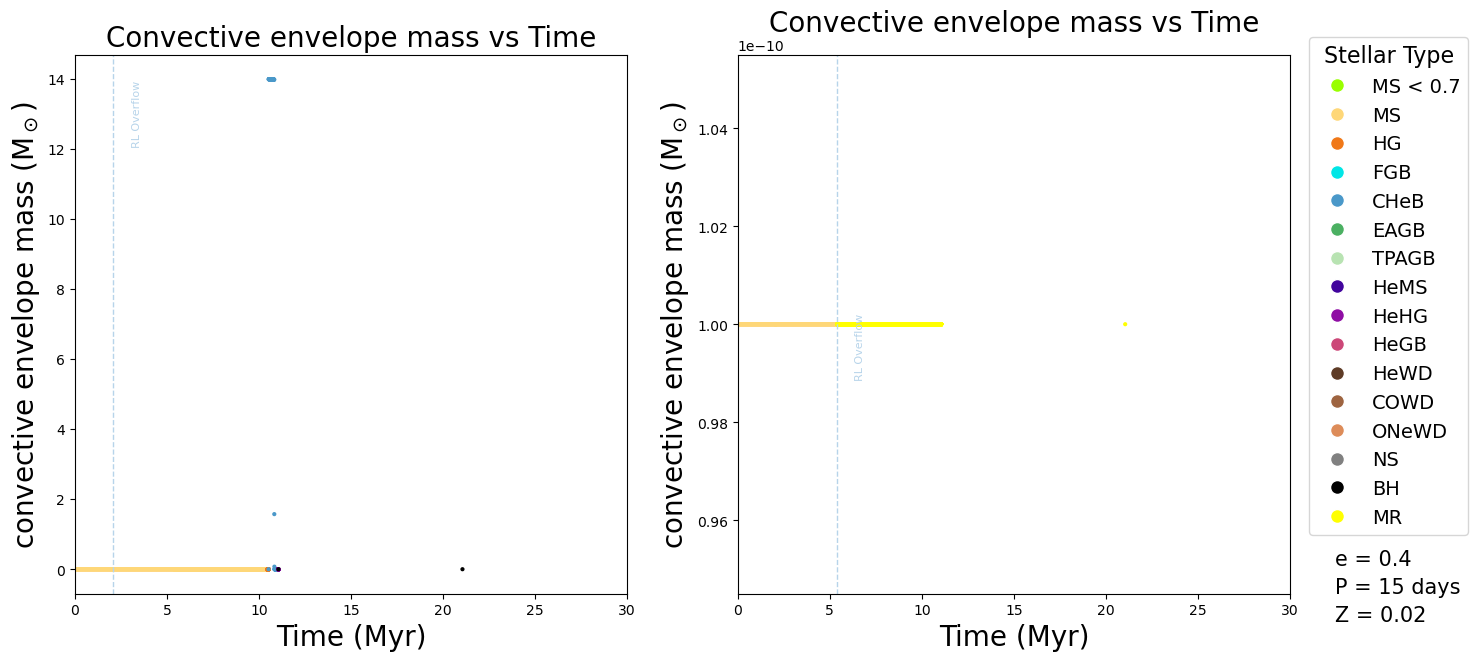

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    df["Time"], 
    df["convective_envelope_mass_1"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_1"]], 
    s=4
)
ax1.set_xlim(xmin=0.0, xmax=x_max)
#ax1.plot(df["Time"], df["convective_envelope_mass_1"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlabel('Time (Myr)',fontsize=20)
ax1.set_ylabel(r'convective envelope mass (M$_\odot$)',fontsize=20)
ax1.set_title('Convective envelope mass vs Time',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    df["Time"], 
    df["convective_envelope_mass_2"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_2"]], 
    s=4
)
ax2.set_xlim(xmin=0.0, xmax=x_max)
#ax2.plot(df["Time"], df["convective_envelope_mass_2"], lw=0.5, color='black', linestyle='--',zorder=-1)
ax2.set_xlabel('Time (Myr)',fontsize=20)
ax2.set_ylabel(r'convective envelope mass (M$_\odot$)',fontsize=20)
ax2.set_title('Convective envelope mass vs Time',fontsize=20)


# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(0, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=14,
    title_fontsize=16,
    loc='center right',
    bbox_to_anchor=(0.9, 0.55),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

# Primary star - see mass transfer
mask_primary = df["R1/ROL1"] >= 1
if mask_primary.any():  # only if there is at least one True
    mass_transfer_time_primary = df["Time"][mask_primary].min()
    # draw vertical dashed line and annotate
    ax1.axvline(x=mass_transfer_time_primary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax1.text(mass_transfer_time_primary+1, ax1.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

# Secondary star - see mass transfer
mask_secondary = df["R2/ROL2"] >= 1
if mask_secondary.any():
    mass_transfer_time_secondary = df["Time"][mask_secondary].min()
    ax2.axvline(x=mass_transfer_time_secondary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax2.text(mass_transfer_time_secondary+1, ax2.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "convective_envelope_mass_vs_Time"


save_name = f"{base_name}_{img_title}.png"
save_dir = "./output_plots/"
save_path = os.path.join(save_dir, save_name)

fig.savefig(save_path, dpi=300, bbox_inches="tight")

# type of enery transportation
# radiative, convective env
# during Ms, no conv env, only radiative env and convective core
# after MS, conv env develop -- have a cnvective core, radiative layer on top,after that con env on top

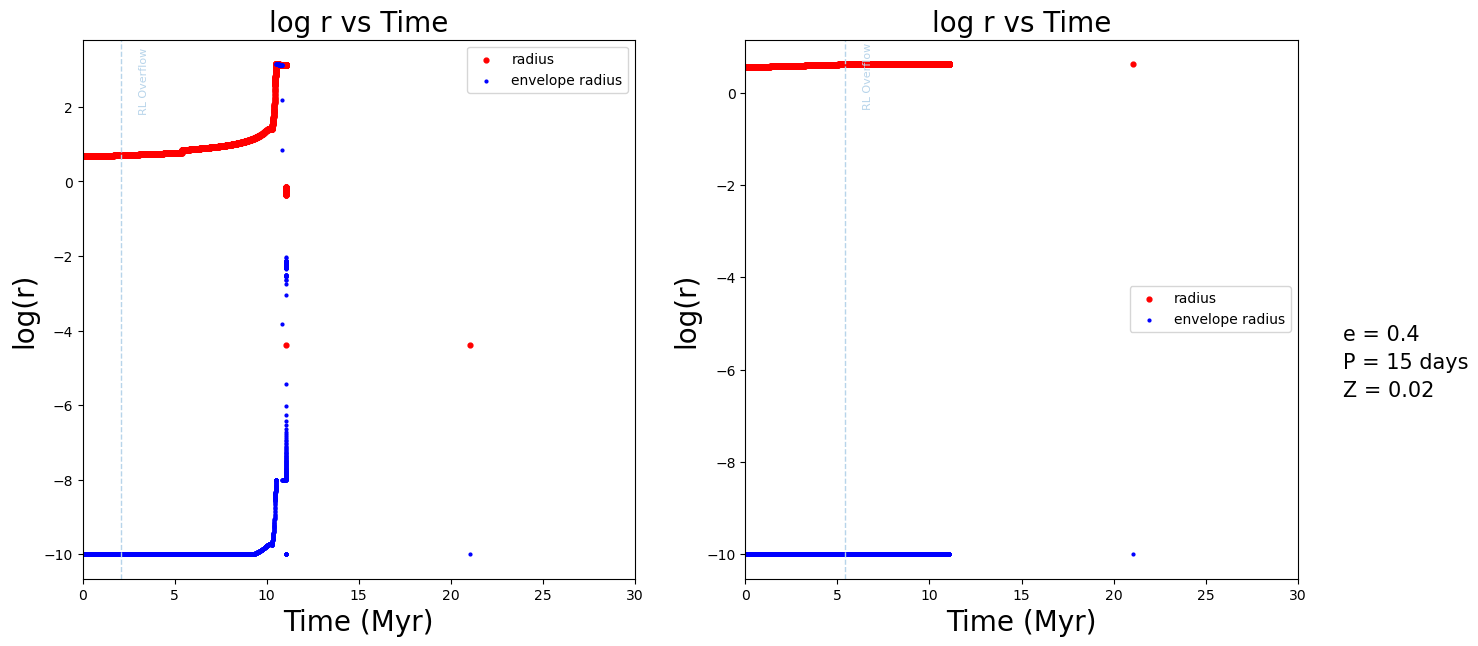

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    df["Time"], 
    df["log10_r_1"], color ="red", 
    s=12, label="radius"
)
ax1.scatter(
    df["Time"], 
    np.log10(df["envelope_radius_1"]), color ="blue", 
    s=4, label="envelope radius"
)
ax1.legend()
ax1.set_xlim(xmin=0.0, xmax=x_max)
ax1.set_xlabel('Time (Myr)',fontsize=20)
ax1.set_ylabel('log(r)',fontsize=20)
ax1.set_title('log r vs Time',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    df["Time"], 
    df["log10_r_2"], color ="red", label="radius",
    s=12
)
ax2.scatter(
    df["Time"], 
    np.log10(df["envelope_radius_2"]), color ="blue", label="envelope radius",
    s=4
)
ax2.legend()
ax2.set_xlim(xmin=0.0, xmax=x_max)
ax2.set_xlabel('Time (Myr)',fontsize=20)
ax2.set_ylabel('log(r)',fontsize=20)
ax2.set_title('log r vs Time',fontsize=20)

y0 = 0.45
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

# Primary star - see mass transfer
mask_primary = df["R1/ROL1"] >= 1
if mask_primary.any():  # only if there is at least one True
    mass_transfer_time_primary = df["Time"][mask_primary].min()
    # draw vertical dashed line and annotate
    ax1.axvline(x=mass_transfer_time_primary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax1.text(mass_transfer_time_primary+1, ax1.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

# Secondary star - see mass transfer
mask_secondary = df["R2/ROL2"] >= 1
if mask_secondary.any():
    mass_transfer_time_secondary = df["Time"][mask_secondary].min()
    ax2.axvline(x=mass_transfer_time_secondary, color=(0.716186, 0.833203, 0.916155, 1.0), linestyle='--', lw=1)
    ax2.text(mass_transfer_time_secondary+1, ax2.get_ylim()[1]*0.95, 'RL Overflow',
             color=(0.716186, 0.833203, 0.916155, 1.0), rotation=90, verticalalignment='top', fontsize=8)

fig.subplots_adjust(right=0.8)  # leave space for legend

plt.show()

img_title = "logR_log_con_r_vs_Time"


save_name = f"{base_name}_{img_title}.png"
save_dir = "./output_plots/"
save_path = os.path.join(save_dir, save_name)

fig.savefig(save_path, dpi=300, bbox_inches="tight")
# where env start - env radius

In [18]:
# fig, ax = plt.subplots()
# ax.set_xlim(xmin=0.0, xmax=x_max)
# # plot the primary star
# ax.scatter(col["time_Myr"], col["m1_Msun"], c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
#    for k in col["k1"]], s=2)
# ax.plot(col["time_Myr"], col["m1_Msun"], lw=0.5, color='black', zorder=-1)

# # plot the secondary star
# ax.scatter(col["time_Myr"], col["m2_Msun"], c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
#    for k in col["k2"]], s=2)
# ax.plot(col["time_Myr"], col["m2_Msun"], lw=0.5, color='black', zorder=-1)


# ax.set_xlabel(r'Time (Myr)')
# ax.set_ylabel(r'Mass (M$_\odot$)')
# ax.set_title('Mass vs Time')

# for kstar in range(1,15):
#     ax.scatter([], [], c=[kstar_translator[kstar]["colour"]], label=kstar_translator[kstar]["short"], s=10)
#     ax.legend(title='Stellar Type', fontsize=6, title_fontsize=9, loc='lower right')

# ax.legend(
#     title='Stellar Type',
#     fontsize=8,
#     title_fontsize=10,
#     loc='center left',            # anchor point of legend
#     bbox_to_anchor=(1.02, 0.5),   # x=1.02 means just outside the right, y=0.5 = vertical center
#     borderaxespad=0               # optional: reduce padding
# )


# fig.subplots_adjust(right=0.8)   # leave space on the right

# img_title = "Mass_vs_Time_one_plot"


# save_name = f"{base_name}_{img_title}.png"

# fig.savefig(save_name, dpi=300, bbox_inches="tight")